# FullereneNet — Cell-Complex Dataset Exploration

`FullereneComplexDataset` (in `fullerene_complex_dataset.py`) represents each fullerene cage
as a 2-dimensional cell complex — atoms (rank 0), bonds (rank 1) and rings (rank 2, from SSSR) —
using the **same featurization and incidence/adjacency construction as `mol3d_ct_rand.Mol3dCTRand`**.

| Name | Molecules | Size range | Split role |
|------|-----------|------------|------------|
| `c60` | 5770 | C20–C60 | train/val (C20–C58) + test (C60) |
| `c70_non_IPR` | 100 | C70 non-IPR | external test |
| `c72_100_IPR` | 1230 | C72–C100 IPR | external test |

Each molecule is returned as `(x_0, x_1, x_2, icd01, icd02, icd12, adj00, adj11, adj22, y)`.

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from fullerene_complex_dataset import FullereneComplexDataset, LABEL_FILES

plt.rcParams['figure.dpi'] = 120

## 1. Load Datasets

Built directly from the XYZ files (no precomputed `.pt` features needed).

In [2]:
datasets = {
    name: FullereneComplexDataset(name, root='.', target='Eb')
    for name in ['c60', 'c70_non_IPR', 'c72_100_IPR']
}

print('Loaded datasets:')
for name, ds in datasets.items():
    print(f'  {name}: {len(ds)} molecules  (atom_dim={ds.rk0_dim}, bond_dim={ds.rk1_dim}, ring_dim={ds.rk2_dim})')

/Users/philippwolf/platonian_solids_exp/FullereneNet/fullerene_complex_dataset.py:141: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  icd01 = torch.sparse_coo_tensor(


Loaded datasets:
  c60: 5770 molecules  (atom_dim=11, bond_dim=8, ring_dim=6)
  c70_non_IPR: 100 molecules  (atom_dim=11, bond_dim=8, ring_dim=6)
  c72_100_IPR: 1230 molecules  (atom_dim=11, bond_dim=8, ring_dim=6)


## 2. Feature & Matrix Descriptions

### Atom feature `x_0` — shape `(N_atoms, 11)`
`atomic_num, total_valence, degree, implicit_valence, is_aromatic, chiral_tag, formal_charge, hybridization, x, y, z`

### Bond feature `x_1` — shape `(N_bonds, 8)`
`bond_type, is_conjugated, in_ring, stereo, is_plain_single_bond, min_ring_size, has_heteroatom(N/O), |EN_a - EN_b|`

### Ring feature `x_2` — shape `(N_rings, 6)`  (rings from `Chem.GetSymmSSSR`)
`ring_size, all_aromatic, n_heteroatoms, all_single_bonds, fused_with_other_ring, mean_electronegativity`

### Incidence matrices (sparse, sizes `N_atoms × N_bonds`, `N_atoms × N_rings`, `N_bonds × N_rings`)
`icd01` (atom–bond), `icd02` (atom–ring), `icd12` (bond–ring)

### Adjacency matrices (sparse, up-adjacency between cells of equal rank)
`adj00 = (icd01 icd01ᵀ) > 0`, `adj11 = (icd01ᵀ icd01) > 0`, `adj22 = (icd12ᵀ icd12) > 0`

In [3]:
# Show tensor shapes for one example molecule from each dataset
labels_in_order = ['x_0 (atom)', 'x_1 (bond)', 'x_2 (ring)',
                   'icd01', 'icd02', 'icd12', 'adj00', 'adj11', 'adj22']

print(f"{'Tensor':<14} {'c60[0]':<22} {'c70_non_IPR[0]':<22} {'c72_100_IPR[0]'}")
print('-' * 84)
for i, label in enumerate(labels_in_order):
    shapes = [str(tuple(datasets[n][0][i].shape)) for n in ['c60', 'c70_non_IPR', 'c72_100_IPR']]
    print(f"  {label:<12} {shapes[0]:<22} {shapes[1]:<22} {shapes[2]}")

Tensor         c60[0]                 c70_non_IPR[0]         c72_100_IPR[0]
------------------------------------------------------------------------------------
  x_0 (atom)   (20, 11)               (70, 11)               (72, 11)
  x_1 (bond)   (30, 8)                (105, 8)               (108, 8)
  x_2 (ring)   (12, 6)                (37, 6)                (38, 6)
  icd01        (20, 30)               (70, 105)              (72, 108)
  icd02        (20, 12)               (70, 37)               (72, 38)
  icd12        (30, 12)               (105, 37)              (108, 38)
  adj00        (20, 20)               (70, 70)               (72, 72)
  adj11        (30, 30)               (105, 105)             (108, 108)
  adj22        (12, 12)               (37, 37)               (38, 38)


## 3. Example Molecule

In [4]:
# C60 (Buckminsterfullerene) is the last entry in the c60 dataset
idx = -1
x0, x1, x2, icd01, icd02, icd12, adj00, adj11, adj22, y = datasets['c60'][idx]

print('=== C60 example (last entry in c60 dataset) ===')
print(f'Atoms:     {x0.shape[0]}')
print(f'Bonds:     {x1.shape[0]}')
print(f'Rings:     {x2.shape[0]}')
print(f'Target Eb: {y.item():.4f} eV')
print()
print('Atom features (first 5 atoms):')
print(x0[:5])
print()
print('Bond features (first 5 bonds):')
print(x1[:5])
print()
print('Ring sizes (12 pentagons + 20 hexagons expected):')
print(x2[:, 0].tolist())

=== C60 example (last entry in c60 dataset) ===
Atoms:     60
Bonds:     90
Rings:     32
Target Eb: -6.5791 eV

Atom features (first 5 atoms):
tensor([[ 6.0000,  4.0000,  3.0000,  0.0000,  1.0000,  0.0000,  0.0000,  2.0000,
         -0.7395,  1.0263, -5.7874],
        [ 6.0000,  4.0000,  3.0000,  0.0000,  1.0000,  0.0000,  0.0000,  2.0000,
          0.7395,  1.0263, -5.7874],
        [ 6.0000,  4.0000,  3.0000,  0.0000,  1.0000,  0.0000,  0.0000,  2.0000,
          1.1764, -0.3698, -5.7749],
        [ 6.0000,  4.0000,  3.0000,  0.0000,  1.0000,  0.0000,  0.0000,  2.0000,
         -1.1764, -0.3698, -5.7749],
        [ 6.0000,  4.0000,  3.0000,  0.0000,  1.0000,  0.0000,  0.0000,  2.0000,
          0.0000, -1.2176, -5.7740]])

Bond features (first 5 bonds):
tensor([[4., 1., 1., 0., 0., 5., 0., 0.],
        [4., 1., 1., 0., 0., 5., 0., 0.],
        [4., 1., 1., 0., 0., 5., 0., 0.],
        [4., 1., 1., 0., 0., 5., 0., 0.],
        [4., 1., 1., 0., 0., 5., 0., 0.]])

Ring sizes (12 pentag

## 4. Dataset Size Statistics

In [5]:
for name, ds in datasets.items():
    n_atoms = [d[0].shape[0] for d in ds]
    n_bonds = [d[1].shape[0] for d in ds]
    n_rings = [d[2].shape[0] for d in ds]
    print(f'--- {name} ---')
    print(f'  Molecules : {len(ds)}')
    print(f'  Atoms     : min={min(n_atoms)}, max={max(n_atoms)}, unique={sorted(set(n_atoms))}')
    print(f'  Bonds     : min={min(n_bonds)}, max={max(n_bonds)}')
    print(f'  Rings     : min={min(n_rings)}, max={max(n_rings)}')
    print()

--- c60 ---
  Molecules : 5770
  Atoms     : min=20, max=60, unique=[20, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]
  Bonds     : min=30, max=90
  Rings     : min=12, max=32

--- c70_non_IPR ---
  Molecules : 100
  Atoms     : min=70, max=70, unique=[70]
  Bonds     : min=105, max=105
  Rings     : min=37, max=37

--- c72_100_IPR ---
  Molecules : 1230
  Atoms     : min=72, max=100, unique=[72, 74, 76, 78, 80, 82, 84, 86, 90, 92, 94, 96, 98, 100]
  Bonds     : min=108, max=150
  Rings     : min=38, max=52



## 5. Label Statistics

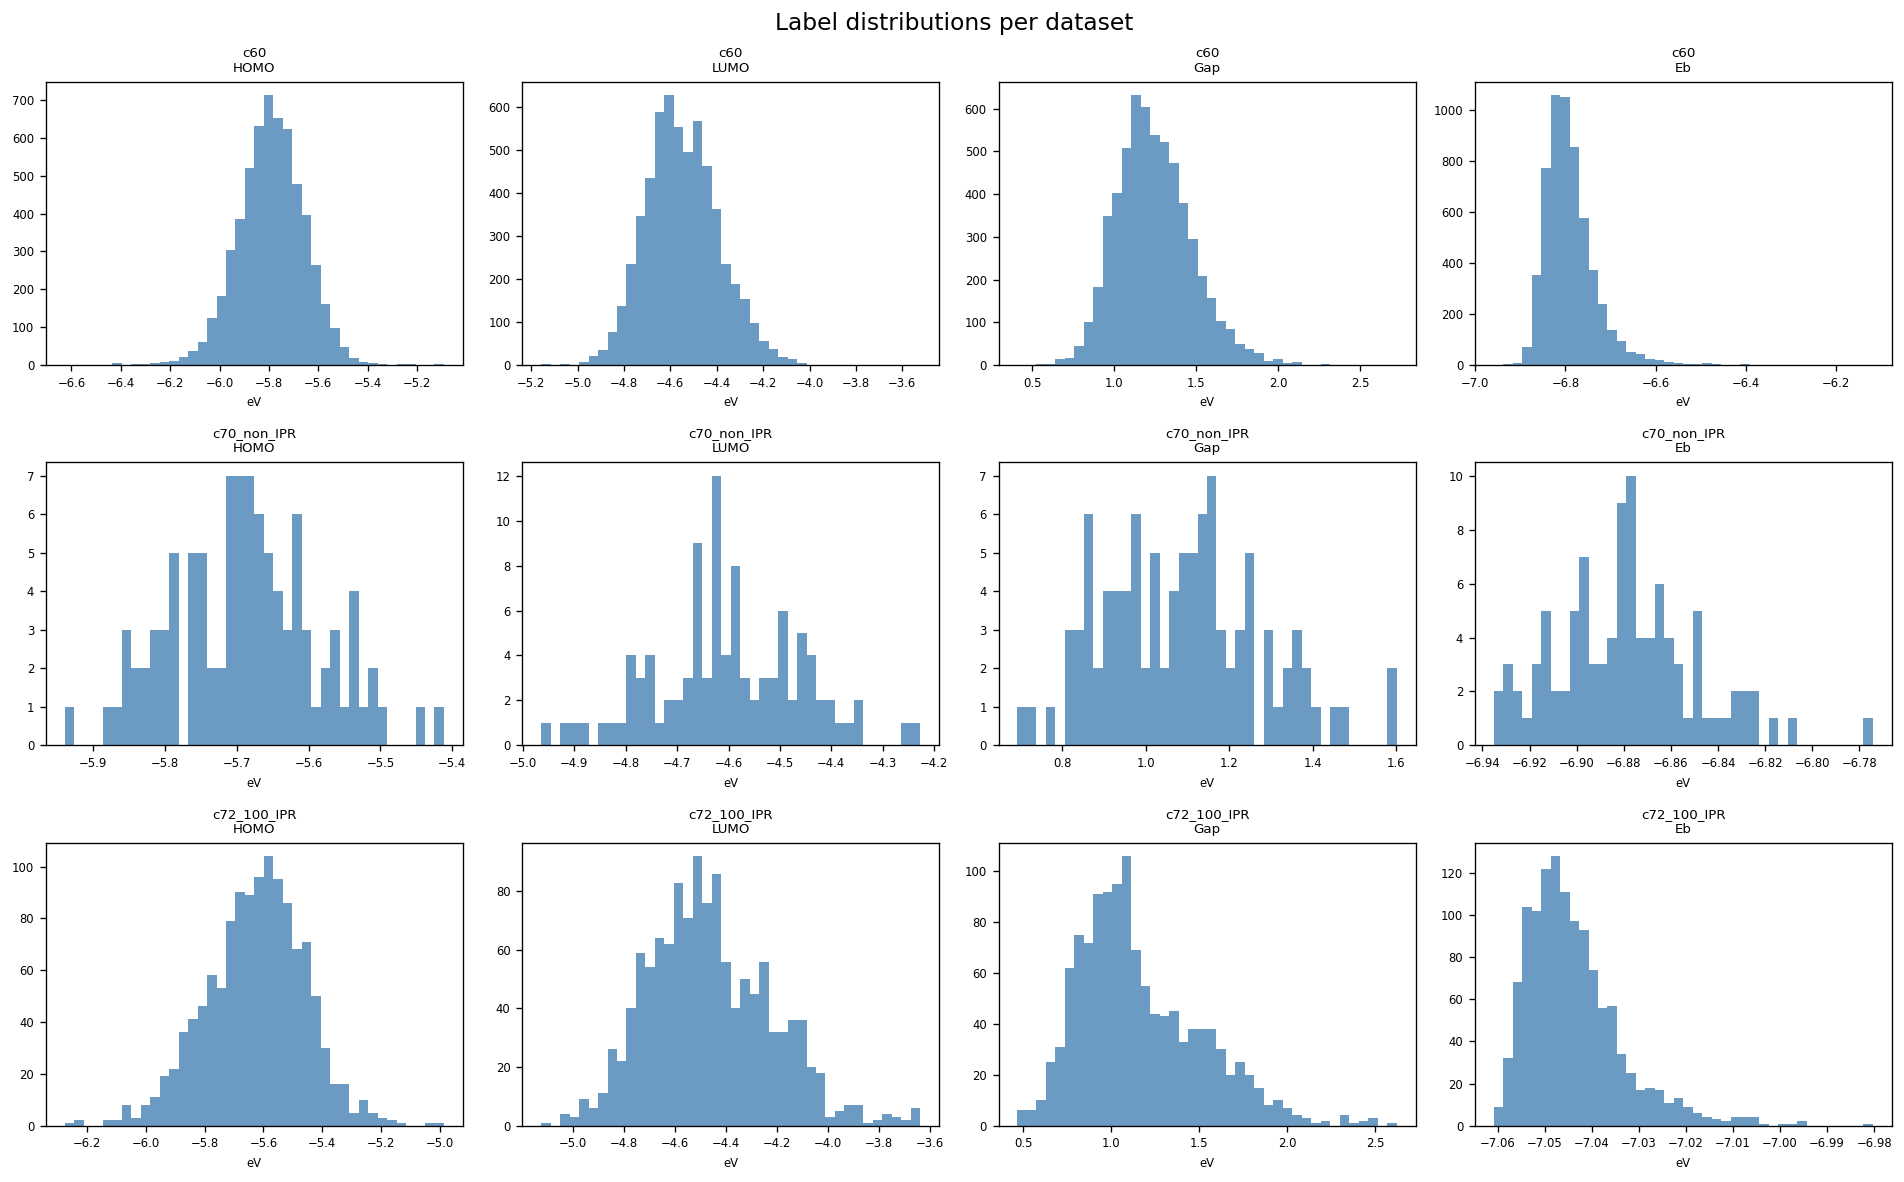

In [6]:
label_dfs = {name: pd.read_csv(f'data/{LABEL_FILES[name]}') for name in datasets}
target_cols = {'HOMO': 'HOMO(eV)', 'LUMO': 'LUMO(eV)', 'Gap': 'HOMO-LUMO(eV)', 'Eb': 'E_binding(eV)'}

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Label distributions per dataset', fontsize=14)

for row, name in enumerate(datasets):
    df = label_dfs[name]
    for col_idx, (label, col) in enumerate(target_cols.items()):
        ax = axes[row, col_idx]
        ax.hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='none', alpha=0.8)
        ax.set_title(f'{name}\n{label}', fontsize=8)
        ax.set_xlabel('eV', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

## 6. Atom Feature Summary
Unlike the original one-hot encodings, atom features here are raw numeric/physical quantities.

In [7]:
atom_cols = ['atomic_num', 'total_valence', 'degree', 'implicit_valence', 'is_aromatic',
             'chiral_tag', 'formal_charge', 'hybridization', 'x', 'y', 'z']

for name, ds in datasets.items():
    all_atoms = torch.cat([d[0] for d in ds], dim=0).numpy()
    df = pd.DataFrame(all_atoms, columns=atom_cols)
    print(f'--- {name}: atom feature summary ({len(df)} atoms) ---')
    print(df.describe().loc[['mean', 'std', 'min', 'max']].round(2))
    print()

--- c60: atom feature summary (322040 atoms) ---
      atomic_num  total_valence  degree  implicit_valence  is_aromatic  \
mean         6.0            4.0     3.0               0.0          1.0   
std          0.0            0.0     0.0               0.0          0.0   
min          6.0            4.0     3.0               0.0          1.0   
max          6.0            4.0     3.0               0.0          1.0   

      chiral_tag  formal_charge  hybridization     x     y    z  
mean         0.0            0.0            2.0  0.00 -0.00 -0.0  
std          0.0            0.0            0.0  1.99  2.04  2.0  
min          0.0            0.0            2.0 -5.35 -5.63 -5.9  
max          0.0            0.0            2.0  5.34  5.63  5.9  

--- c70_non_IPR: atom feature summary (7000 atoms) ---
      atomic_num  total_valence  degree  implicit_valence  is_aromatic  \
mean         6.0            4.0     3.0               0.0          1.0   
std          0.0            0.0     0.0       

## 7. Bond Type Distribution
`bond_type`: 1=SINGLE, 2=DOUBLE, 3=TRIPLE, 4=AROMATIC (as perceived by `rdDetermineBonds`).

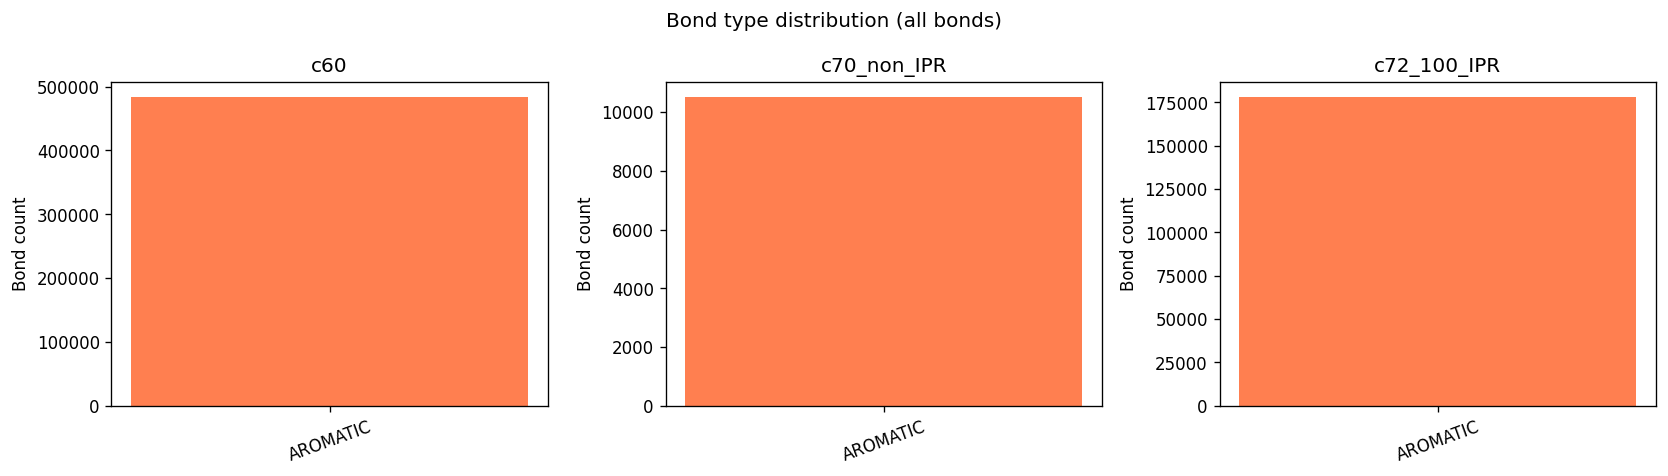

In [8]:
bond_type_names = {1: 'SINGLE', 2: 'DOUBLE', 3: 'TRIPLE', 4: 'AROMATIC'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Bond type distribution (all bonds)', fontsize=12)

for ax, name in zip(axes, datasets):
    all_bonds = torch.cat([d[1] for d in datasets[name]], dim=0)
    types, counts = np.unique(all_bonds[:, 0].numpy().astype(int), return_counts=True)
    ax.bar([bond_type_names.get(t, str(t)) for t in types], counts, color='coral')
    ax.set_title(name)
    ax.set_ylabel('Bond count')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 8. Ring Size Distribution
Fullerenes contain only pentagons (size 5) and hexagons (size 6).

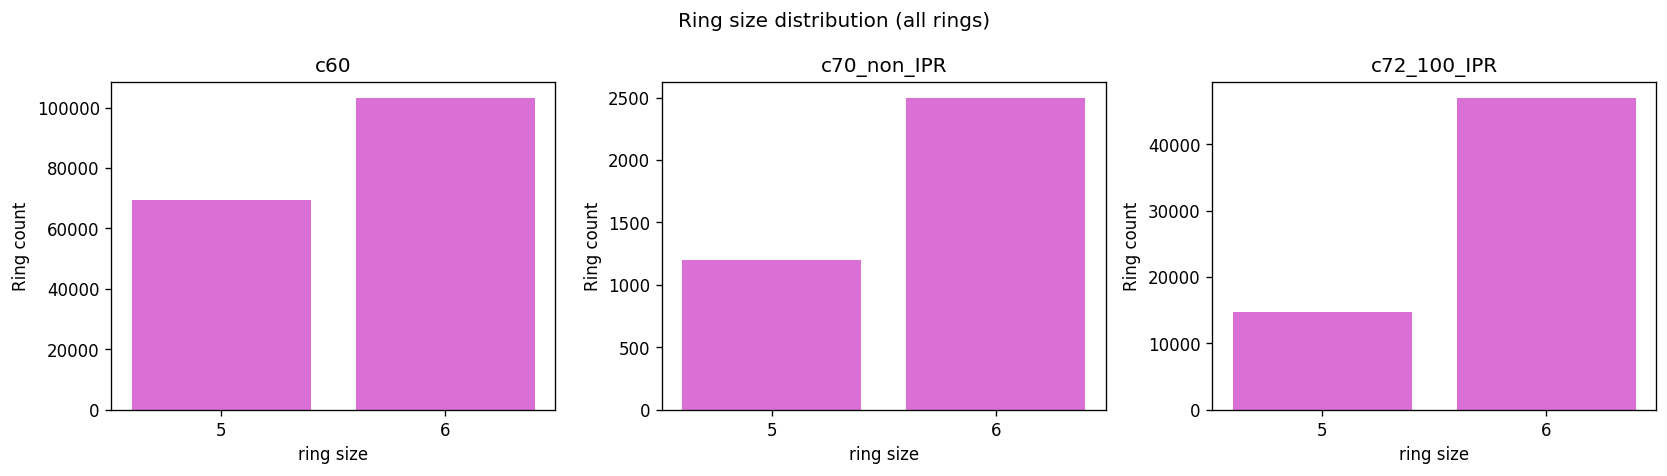

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Ring size distribution (all rings)', fontsize=12)

for ax, name in zip(axes, datasets):
    all_rings = torch.cat([d[2] for d in datasets[name]], dim=0)
    sizes, counts = np.unique(all_rings[:, 0].numpy().astype(int), return_counts=True)
    ax.bar([str(s) for s in sizes], counts, color='orchid')
    ax.set_title(name)
    ax.set_ylabel('Ring count')
    ax.set_xlabel('ring size')

plt.tight_layout()
plt.show()

## 9. Per-size Isomer Counts (c60 dataset)

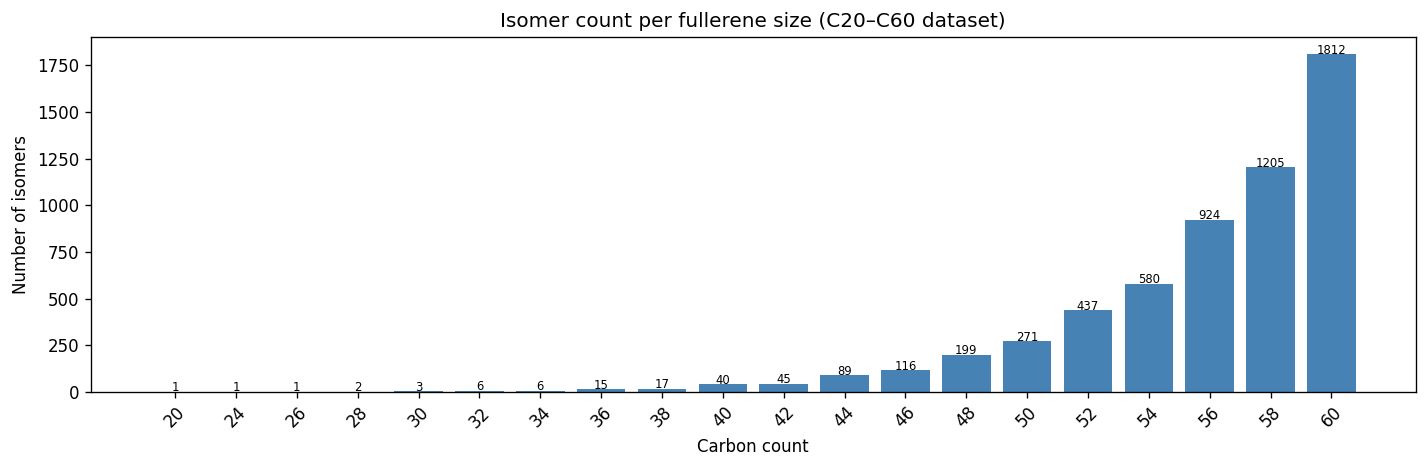

In [10]:
df = label_dfs['c60']
iso_counts = df.groupby('#C').size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(iso_counts.index.astype(str), iso_counts.values, color='steelblue')
ax.set_xlabel('Carbon count')
ax.set_ylabel('Number of isomers')
ax.set_title('Isomer count per fullerene size (C20–C60 dataset)')
ax.tick_params(axis='x', rotation=45)
for x, v in zip(range(len(iso_counts)), iso_counts.values):
    ax.text(x, v + 2, str(v), ha='center', fontsize=7)
plt.tight_layout()
plt.show()

## 10. Summary Table

In [11]:
rows = []
for name, ds in datasets.items():
    rows.append({
        'Dataset': name,
        'Molecules': len(ds),
        'Atom feat dim': ds.rk0_dim,
        'Bond feat dim': ds.rk1_dim,
        'Ring feat dim': ds.rk2_dim,
        'Rings/mol (min-max)': f'{min(d[2].shape[0] for d in ds)}-{max(d[2].shape[0] for d in ds)}',
    })

pd.DataFrame(rows).set_index('Dataset')

,Molecules,Atom feat dim,Bond feat dim,Ring feat dim,Rings/mol (min-max)
Dataset,,,,,
c60,5770,11,8,6,12-32
c70_non_IPR,100,11,8,6,37-37
c72_100_IPR,1230,11,8,6,38-52
